# Markov Chain Comparison
In this file, we use data of trajectories of choanoflagelates confined in a 2D plan before and after addition of different substances:
- **RS39604** is a synthetic agonist that activates our ion channel.
- **15M9E** is a natural product purified from bacteria that also activates the channel.
- **Algoriphagus** machipongonensis is the bacterium from which 15M9E was purified, and a natural prey source for this choanoflagellate species.

The notebook is organized as follow:
1. Import and convert the data.
2. Make the embedding.
3. Clusterize all the data togethers and Make the Markov chains
4. Compare the Markov Chains.


# Import the xml files and convert xml into dataframes

In [1]:
import sys
sys.path.append('../../src')
from xml_df_parser import trackmate_xml_to_df
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
folder = "../../data/Algoriphagus/"
xml_files = ["Expt1_251217_Pre", "Expt1_251217_Post"]
ext = ".xml"
dfs = list()
for file in xml_files:
    dfs.append(trackmate_xml_to_df(folder+file+ext))


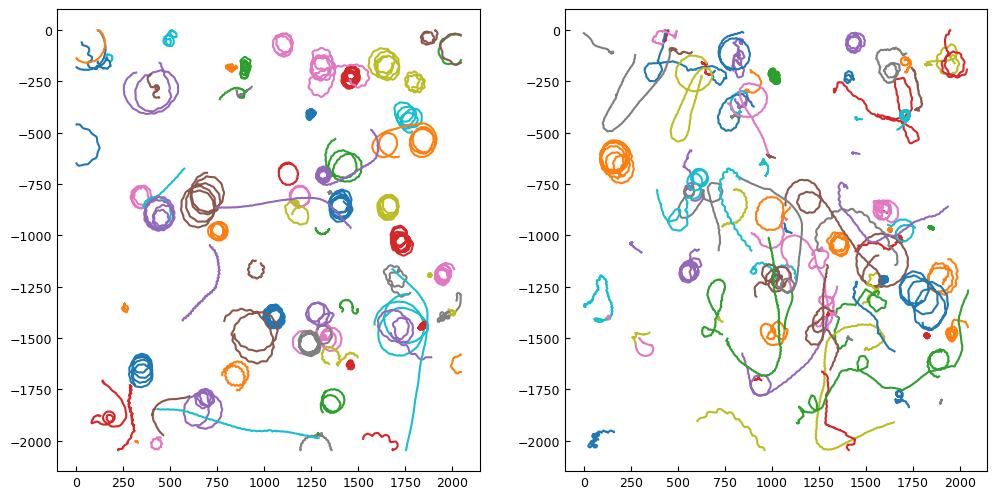

In [3]:
fig,ax = plt.subplots(ncols=len(dfs),figsize=(6*len(dfs),6))
for i in range(len(dfs)):
    for id,track in dfs[i].groupby('Track_ID'):
        ax[i].plot(track['X'],-track['Y'])



In [4]:
print(dfs[0].head())

     Spot_ID  Track_ID  Frame           X            Y    Z
0       2178         0      0  400.400844  1634.425105  0.0
69      2483         0      1  399.938974  1629.545128  0.0
124     2627         0      2  399.417460  1626.611111  0.0
157     2696         0      3  399.428875  1624.386412  0.0
213     2582         0      4  399.416402  1622.438624  0.0


## Currate and make embedding

In [5]:
sys.path.append('../..')
from src.embedding_trans import EmbeddingTrans
from src.markov_analysis import MarkovFromEmbedding,MultiMarkov
columns_abs = []
columns_translated = ['X','Y']
id = 'Track_ID'
time = 'Frame'
cols = ['X','Y']


/home/hugo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
embs = list()
for df in dfs:    
    embs.append(EmbeddingTrans(df, columns=columns_abs,columns_translated = columns_translated,ID_NAME=id))

In [7]:
Klist = [3,5,10,25,50,100]
nc_list = [10,20,50,100]

H = np.zeros((len(embs),len(Klist),len(nc_list)),dtype=float)

for i,K in enumerate(Klist):
    print(i)
    for emb in embs:
        emb.make_embedding(K=K)
    for j,nc in enumerate(nc_list):
        for emb in embs:
            emb.make_cluster(n_clusters=nc)
        mkvs = list()
        for emb in embs:
            mkvs.append(MarkovFromEmbedding(emb,tau=1))
        for k,mkv in enumerate(mkvs):
            H[k,i,j] = mkv.compute_entropy_rate()

0
1
2
3
4
5


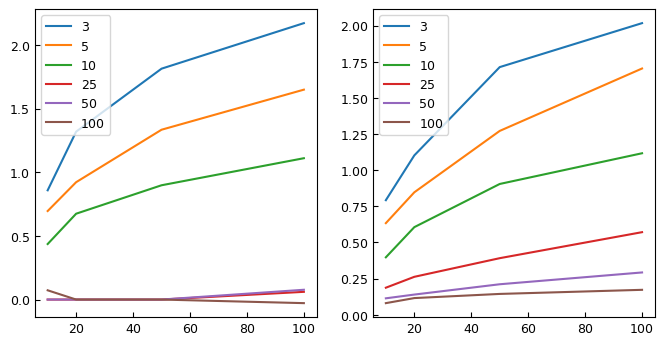

In [8]:
fig,ax = plt.subplots(ncols = len(embs),figsize=(4*len(embs),4))
for k in range(H.shape[0]):
    for i,h in enumerate(H[k]):
        ax[k].plot(nc_list,h,label=Klist[i])
    ax[k].legend()

In [12]:
for emb in embs:
    emb.make_embedding(K=10)
    emb.make_cluster(n_clusters=100)

mkvs = list()
for emb in embs:
    mkvs.append(MarkovFromEmbedding(emb,tau=1))

In [28]:
import awkward as ak
import importlib
import src.cluster
importlib.reload(src.cluster)
from src.cluster import Cluster
from scipy.special import entr

In [29]:
nc_com_list = [10,20,30,40,50,60,70,80,90,100,200,500,1000]
H_mix = list()
for nc in nc_com_list:
    clt = Cluster(nc)
    clt.add_embedding(embs[0])
    clt.add_embedding(embs[1])
    clt.set_shape_and_flatten()
    clt.clusterize()
    prop = clt.compute_proportions()
    H_mix.append((np.sum(entr(prop),axis=1)))
H_mix = ak.Array(H_mix)

1000


Text(0, 0.5, 'mixing entropy of the clusters')

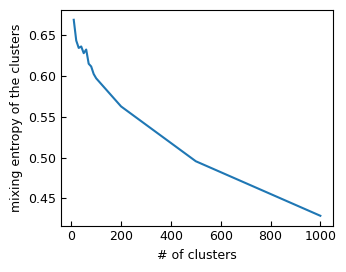

In [30]:
plt.plot(nc_com_list,ak.mean(H_mix,axis=1))
print(nc_com_list[np.argmin(ak.mean(H_mix,axis=1))])
plt.xlabel('# of clusters')
plt.ylabel('mixing entropy of the clusters')

In [32]:
clt = Cluster(100)
clt.add_embedding(embs[0])
clt.add_embedding(embs[1])
clt.set_shape_and_flatten()
clt.clusterize()


In [36]:
mmkv = MultiMarkov(clt)

In [37]:
h_list = np.sum(entr(clt.compute_proportions()),axis=1) # compute the mixing entropy of every cluster
partitions = list()
n_partition = 5
hmin = 10**-10
reduced_systems = list()
for i in range(mmkv.__len__()):
    print()
    # add a loop to isolate the empty clusters
    keep = True
    isolated =list() # store the isolated clusters
    reduced_system = np.arange(mmkv[i].n_clusters) # start by considering every cluster
    while keep:
        partition = mmkv[i].recursive_partition(2,reduced_system = reduced_system)
        for part in partition:
            if all(h_list[part] <=hmin):
                keep = True
                for val in part:
                    reduced_system = reduced_system[~np.isin(reduced_system, part)]
                break
            keep = False
    reduced_systems.append(reduced_system)


In [38]:
partitions= list()
for i in range(len(mmkv)):
    partitions.append(mmkv[i].recursive_partition(3,reduced_system = reduced_systems[i]))

In [39]:
clt.fit_umap(with_cluster_centers=False)

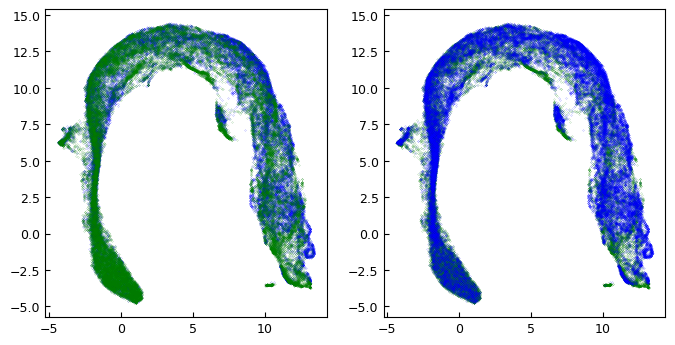

In [44]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].scatter(ak.flatten(clt.reduced_pts[0])[:,0],ak.flatten(clt.reduced_pts[0])[:,1],s=0.01,alpha=1.,c='b')
ax[0].scatter(ak.flatten(clt.reduced_pts[1])[:,0],ak.flatten(clt.reduced_pts[1])[:,1],s=0.01,alpha=1.,c='g')


ax[1].scatter(ak.flatten(clt.reduced_pts[1])[:,0],ak.flatten(clt.reduced_pts[1])[:,1],s=0.01,alpha=1.,c='g')
ax[1].scatter(ak.flatten(clt.reduced_pts[0])[:,0],ak.flatten(clt.reduced_pts[0])[:,1],s=0.01,alpha=1.,c='b')

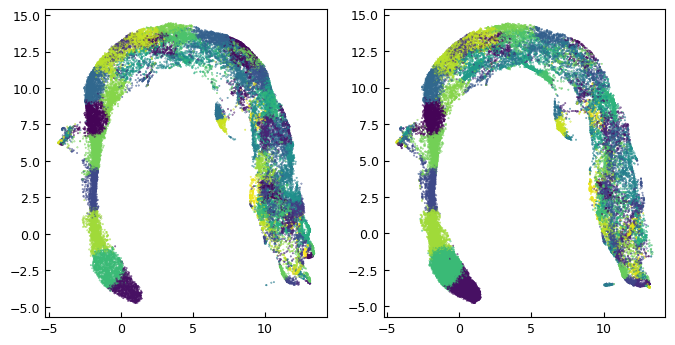

In [46]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))

for i in range(2):
    ax[i].scatter(ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],s=0.1,c = ak.flatten(clt.labels[i]))

In [47]:
cluster_to_partition = np.zeros((2,clt.n_clusters), dtype=int)

for i in range(2):
    for partition_idx, cluster_ids in enumerate(partitions[i]):
        cluster_to_partition[i][cluster_ids] = partition_idx

In [48]:
partition_labels = list()
for i in range(2):
    partition_labels.append(ak.Array([cluster_to_partition[i,labels] for labels in clt.labels[i]]))

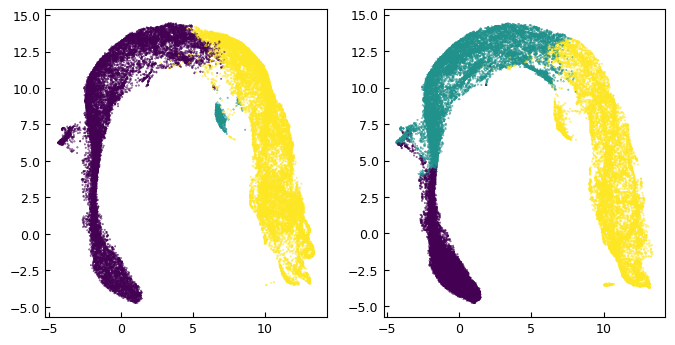

In [50]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))

for i in range(2):
    ax[i].scatter(ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],s=0.1,c = ak.flatten(partition_labels[i]))

In [53]:
# save the files to investigate with the dash app
folder = "../../data/Algoriphagus/"
parquet_files = ["Expt1_251217_Pre_umap.parquet", "Expt1_251217_Post_umap.parquet"]
color_files = ['coarse_grained_Pre.parquet','coarse_grained_Post.parquet']
for i in range(len(clt.reduced_pts)):
    ak.to_parquet(clt.reduced_pts[i],folder+parquet_files[i])
    ak.to_parquet(partition_labels[i],folder + color_files[i])



In [ ]:
import pickle

for emb in embs:
    with open(folder, 'wb') as f:
    pickle.dump(clt, f)